In [82]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, gaussian_kde
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

In [83]:
final_df = pd.read_csv('final_df_corrected_cleaned.csv')
questions = final_df['Question'].unique()

participant_data = final_df[final_df['Question'] == 'Q1']
grouped = participant_data.groupby('GROUP')

def handle_ties(series):
    max_value = series.max()
    return series.index[series == max_value].tolist()

for col in ['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']:
    diversity_results = {}
    majority_results = {}
    for name, group in grouped:
        diversity = group[col].value_counts(normalize=True)
        diversity_num = sum(diversity**2)
        diversity_results[name] = diversity_num
        majority = handle_ties(diversity)
        # can only be one major group
        if len(majority) > 1:
            majority = "No Majority"
        else:
            majority = majority[0]
        majority_results[name] = majority
    diversity_df = pd.DataFrame.from_dict(diversity_results, orient='index', columns=[f'{col}'])
    majority_df = pd.DataFrame.from_dict(majority_results, orient='index', columns=[f'{col}'])
    final_df = final_df.merge(diversity_df, left_on='GROUP', right_index=True, suffixes=('', '_diversity'))
    final_df = final_df.merge(majority_df, left_on='GROUP', right_index=True, suffixes=('', '_majority'))
    final_df[f'{col}_majority'] = final_df.apply(lambda x: True if x[col] == x[f'{col}_majority'] else False, axis=1)
    div_mean = final_df[f'{col}_diversity'].mean()
    div_std = final_df[f'{col}_diversity'].std()
    final_df[f'{col}_diversity'] = final_df.apply(lambda x: (x[f'{col}_diversity'] - div_mean)/div_std, axis=1)

for question in questions:
    # calculate group means
    question_data = final_df[final_df['Question'] == question]
    group_means = question_data.groupby('GROUP')['BeforeNumber'].mean().to_dict()
    final_df.loc[final_df['Question'] == question, 'GroupMean'] = final_df.loc[final_df['Question'] == question, 'GROUP'].map(group_means)

# if after number is closer to group mean than before number, then positive else negative
final_df['delta_human_closer'] = final_df.apply(lambda x: abs(x['AfterNumber']-x['BeforeNumber']) if abs(x['AfterNumber'] - x['GroupMean']) < abs(x['BeforeNumber'] - x['GroupMean']) else -abs(x['AfterNumber']-x['BeforeNumber']), axis=1)
final_df['delta_llm_closer'] = final_df.apply(lambda x: abs(x['Corrected_LLM']-x['BeforeNumber']) if abs(x['Corrected_LLM'] - x['GroupMean']) < abs(x['BeforeNumber'] - x['GroupMean']) else -abs(x['Corrected_LLM']-x['BeforeNumber']), axis=1)

In [84]:
# basic formula for regression
formula = ("delta ~ RACE_Asian_non_Hispanic + RACE_Black_non_Hispanic + "
           "RACE_Hispanic + RACE_Other_non_Hispanic + RACE_White_non_Hispanic + "
           "AGEBRACKET_30_44 + AGEBRACKET_45_59 + AGEBRACKET_60plus + "
           "EDUCATION_HS_graduate_or_equivalent + EDUCATION_No_HS_diploma + "
           "EDUCATION_Some_college + PARTYBEFORE_Independent + "
           "PARTYBEFORE_Republican + GENDER_Male")


models = {}
for question in questions:
    qdf = final_df[final_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    # target is how far off the llm shift is from the human shift
    #y = abs(qdf['delta_human'])
    y = qdf['delta_human_closer']
    df_run = X.copy()
    scaler = StandardScaler()

    df_run['delta'] = scaler.fit_transform(y.values.reshape(-1,1))

    model = smf.ols(formula=formula, data=df_run).fit(cov_type="cluster", cov_kwds={"groups": df_run["Group"]})
    # get r squared
    r_squared = model.rsquared
    
    models[question] = {
        'model': model,
        'r_squared': r_squared
    }

model_df = pd.DataFrame.from_dict(models, orient='index')
model_df = model_df.sort_values(by='r_squared', ascending=False)
model_df.head()

,model,r_squared
Q3G,<statsmodels.regression.linear_model.Regressio...,0.091371
Q2H,<statsmodels.regression.linear_model.Regressio...,0.068362
Q5E,<statsmodels.regression.linear_model.Regressio...,0.064177
Q2I,<statsmodels.regression.linear_model.Regressio...,0.062826
Q5A,<statsmodels.regression.linear_model.Regressio...,0.058753


In [85]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Use the cleaner formula API - it handles dummy creation automatically
# This ensures RACE, AGE, etc. use a reference category correctly
formula = "delta ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"

model_results = []
detailed_coefs = []

for question in questions:
    qdf = final_df[final_df['Question'] == question].copy()
    
    # Define your delta (change this to whatever your target 'delta' variable is)
    # Using the raw difference to keep effect sizes interpretable in "points"
    qdf['delta'] = qdf['delta_human_closer'] 
    
    # Fit MixedLM for interpretation
    # This accounts for Group variance while giving you fixed effect significance
    model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
    
    # 1. Store general model stats
    model_results.append({
        'Question': question,
        'Converged': model.converged,
        'Log-Likelihood': model.llf
    })
    
    # 2. Extract Coefficients, P-values, and Conf. Intervals
    params = model.params
    pvalues = model.pvalues
    conf_int = model.conf_int()
    
    for feat in params.index:
        if feat == "Group Var": continue # Skip the random effect variance term
        detailed_coefs.append({
            'Question': question,
            'Variable': feat,
            'Coefficient': params[feat],
            'P-Value': pvalues[feat],
            'Lower_CI': conf_int.loc[feat, 0],
            'Upper_CI': conf_int.loc[feat, 1]
        })
    # add group variance
    detailed_coefs.append({
        'Question': question,
        'Variable': "Group Var",
        'Coefficient': model.cov_re.iloc[0,0],
        'P-Value': np.nan, # No p-value for variance component
        'Lower_CI': np.nan,
        'Upper_CI': np.nan
    })

# Create final dataframes for inspection
summary_df = pd.DataFrame(model_results)
coef_df = pd.DataFrame(detailed_coefs)

# Filter for statistically significant findings (p < 0.05)
significant_findings = coef_df[coef_df['P-Value'] < 0.05].sort_values(by='Coefficient', ascending=False)

print("--- Significant Demographic Effects ---")
print(significant_findings.head(10))

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Sem

--- Significant Demographic Effects ---
    Question                       Variable  Coefficient   P-Value  Lower_CI  \
244      Q3G  C(RACE)[T.Other_non_Hispanic]     5.641417  0.001991  2.064930   
4         Q1  C(RACE)[T.Other_non_Hispanic]     4.832775  0.001237  1.900484   
276      Q4A  C(RACE)[T.Other_non_Hispanic]     4.680574  0.030364  0.443866   
612      Q6F  C(RACE)[T.Other_non_Hispanic]     4.650727  0.010331  1.096415   
100      Q2G  C(RACE)[T.Other_non_Hispanic]     4.215123  0.033967  0.319048   
372      Q4H  C(RACE)[T.Other_non_Hispanic]     3.634671  0.028474  0.382806   
346      Q4E  C(EDUCATION)[T.No_HS_diploma]     2.601763  0.015497  0.495071   
609      Q6F  C(RACE)[T.Asian_non_Hispanic]     2.559402  0.022865  0.355075   
613      Q6F  C(RACE)[T.White_non_Hispanic]     2.429576  0.007350  0.653118   
130      Q2I  C(RACE)[T.Black_non_Hispanic]     2.302140  0.013148  0.482541   

     Upper_CI  
244  9.217905  
4    7.765066  
276  8.917282  
612  8.205038  

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 4.706360
  warnings.warn(msg, ConvergenceWarning)


In [86]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

formula = "delta ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"

model_results = []
detailed_coefs = []

for question in questions:
    qdf = final_df[final_df['Question'] == question].copy()
    
    # Define your delta (change this to whatever your target 'delta' variable is)
    # Using the raw difference to keep effect sizes interpretable in "points"
    qdf['delta'] = qdf['delta_llm_closer'] 
    
    # Fit MixedLM for interpretation
    # This accounts for Group variance while giving you fixed effect significance
    model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
    
    # 1. Store general model stats
    model_results.append({
        'Question': question,
        'Converged': model.converged,
        'Log-Likelihood': model.llf
    })
    
    # 2. Extract Coefficients, P-values, and Conf. Intervals
    params = model.params
    pvalues = model.pvalues
    conf_int = model.conf_int()
    
    for feat in params.index:
        if feat == "Group Var": continue # Skip the random effect variance term
        detailed_coefs.append({
            'Question': question,
            'Variable': feat,
            'Coefficient': params[feat],
            'P-Value': pvalues[feat],
            'Lower_CI': conf_int.loc[feat, 0],
            'Upper_CI': conf_int.loc[feat, 1]
        })
    # add group variance
    detailed_coefs.append({
        'Question': question,
        'Variable': "Group Var",
        'Coefficient': model.cov_re.iloc[0,0],
        'P-Value': np.nan, # No p-value for variance component
        'Lower_CI': np.nan,
        'Upper_CI': np.nan
    })

# Create final dataframes for inspection
summary_df = pd.DataFrame(model_results)
coef_df = pd.DataFrame(detailed_coefs)

# Filter for statistically significant findings (p < 0.05)
significant_findings = coef_df[coef_df['P-Value'] < 0.05].sort_values(by='Coefficient', ascending=False)

print("--- Significant Demographic Effects ---")
print(significant_findings.head(10))

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Sem

--- Significant Demographic Effects ---
    Question                       Variable  Coefficient       P-Value  \
276      Q4A  C(RACE)[T.Other_non_Hispanic]     3.636518  3.590678e-09   
52       Q2D  C(RACE)[T.Other_non_Hispanic]     2.621158  3.481221e-03   
612      Q6F  C(RACE)[T.Other_non_Hispanic]     2.487698  6.618877e-03   
196      Q3D  C(RACE)[T.Other_non_Hispanic]     1.903276  8.830734e-04   
324      Q4D  C(RACE)[T.Other_non_Hispanic]     1.857163  1.571186e-03   
4         Q1  C(RACE)[T.Other_non_Hispanic]     1.767451  4.937395e-02   
141      Q2I   C(PARTYBEFORE)[T.Republican]     1.654879  1.208147e-13   
340      Q4E  C(RACE)[T.Other_non_Hispanic]     1.530143  1.649568e-02   
628      Q6G  C(RACE)[T.Other_non_Hispanic]     1.524395  2.027006e-02   
193      Q3D  C(RACE)[T.Asian_non_Hispanic]     1.522308  4.087918e-06   

     Lower_CI  Upper_CI  
276  2.428891  4.844145  
52   0.862809  4.379507  
612  0.692112  4.283285  
196  0.781484  3.025069  
324  0.705712  

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 8.385091
  warnings.warn(msg, ConvergenceWarning)


In [87]:
# group formula for regression
# basic formula for regression
formula = ("delta ~ RACE_Asian_non_Hispanic + RACE_Black_non_Hispanic + "
           "RACE_Hispanic + RACE_Other_non_Hispanic + RACE_White_non_Hispanic + "
           "AGEBRACKET_30_44 + AGEBRACKET_45_59 + AGEBRACKET_60plus + "
           "EDUCATION_HS_graduate_or_equivalent + EDUCATION_No_HS_diploma + "
           "EDUCATION_Some_college + PARTYBEFORE_Independent + "
           "PARTYBEFORE_Republican + GENDER_Male + RACE_diversity + RACE_majority + "
           "AGEBRACKET_diversity + AGEBRACKET_majority + EDUCATION_diversity + "
           "EDUCATION_majority + PARTYBEFORE_diversity + PARTYBEFORE_majority + "
           "GENDER_diversity + GENDER_majority")

models = {}
for question in questions:
    qdf = final_df[final_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    for col in ['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']:
        X[f'{col}_diversity'] = qdf[f'{col}_diversity']
        X[f'{col}_majority'] = qdf[f'{col}_majority'].astype(int)
    # target is how far off the llm shift is from the human shift
    #y = abs(qdf['delta_human'])
    y = qdf['delta_human_closer']
    df_run = X.copy()
    scaler = StandardScaler()

    df_run['delta'] = scaler.fit_transform(y.values.reshape(-1,1))

    model = smf.ols(formula=formula, data=df_run).fit(cov_type="cluster", cov_kwds={"groups": df_run["Group"]})
    # get r squared
    r_squared = model.rsquared
    adj_r_squared = model.rsquared_adj
    
    models[question] = {
        'model': model,
        'r_squared': r_squared,
        'adj_r_squared': adj_r_squared,
    }

model_df_human = pd.DataFrame.from_dict(models, orient='index')
model_df_human = model_df_human.sort_values(by='r_squared', ascending=False)
model_df_human.head()

,model,r_squared,adj_r_squared
Q3G,<statsmodels.regression.linear_model.Regressio...,0.120662,0.070771
Q6F,<statsmodels.regression.linear_model.Regressio...,0.092464,0.037601
Q4A,<statsmodels.regression.linear_model.Regressio...,0.089687,0.040920
Q2I,<statsmodels.regression.linear_model.Regressio...,0.081903,0.035515
Q5E,<statsmodels.regression.linear_model.Regressio...,0.076891,0.031493


In [88]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Use the cleaner formula API - automatically handles dummy reference categories
formula = "delta ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"

detailed_results = []

for question in questions:
    qdf = final_df[final_df['Question'] == question].copy()
    
    # Target variable (raw scale for interpretable effect sizes)
    qdf['delta'] = qdf['delta_human_closer'] 
    
    try:
        # Fit MixedLM
        model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
        
        # --- CALCULATE R-SQUARED COMPONENTS ---
        # 1. Variance of Fixed Effects (Demographics)
        fixed_preds = model.predict(qdf)
        var_f = np.var(fixed_preds)
        
        # 2. Variance of Random Effects (Group context)
        # model.cov_re is the covariance matrix for random effects
        var_r = float(model.cov_re.iloc[0, 0])
        
        # 3. Residual Variance (Unexplained noise)
        var_e = model.scale
        
        # Marginal R2: Variance explained by demographics only
        marginal_r2 = var_f / (var_f + var_r + var_e)
        # Conditional R2: Variance explained by demographics + group clusters
        conditional_r2 = (var_f + var_r) / (var_f + var_r + var_e)
        
        # --- EXTRACT COEFFICIENTS ---
        params = model.params
        pvalues = model.pvalues
        conf_int = model.conf_int()
        
        for feat in params.index:
            if feat == "Group Var": continue
            
            detailed_results.append({
                'Question': question,
                'Variable': feat,
                'Effect_Size': params[feat], # In original scale units
                'P_Value': pvalues[feat],
                'Lower_CI': conf_int.loc[feat, 0],
                'Upper_CI': conf_int.loc[feat, 1],
                'Marginal_R2': marginal_r2,      # Trust in demographics
                'Conditional_R2': conditional_r2,  # Trust in total model
                'Group_Variance_Prop': var_r / (var_f + var_r + var_e) # How much 'Group' matters
            })
            
    except Exception as e:
        print(f"Skipping {question} due to error: {e}")

# Create DataFrame
results_df = pd.DataFrame(detailed_results)

# --- ADD INTERPRETATION HELPERS ---
def get_trust_level(r2):
    if r2 < 0.02: return "Very Low (Noise)"
    if r2 < 0.10: return "Low/Moderate"
    return "High (Strong Signal)"

results_df['Demographic_Trust'] = results_df['Marginal_R2'].apply(get_trust_level)

# Filter for significant results and sort by the strongest predictors
significant_findings = results_df[results_df['P_Value'] < 0.05].sort_values(
    by=['Marginal_R2', 'Effect_Size'], ascending=[False, False]
)

print(significant_findings[['Question', 'Variable', 'Effect_Size', 'P_Value', 'Marginal_R2', 'Demographic_Trust']].head(20))
results_df_human = results_df.copy()

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Sem

    Question                                   Variable  Effect_Size  \
229      Q3G              C(RACE)[T.Other_non_Hispanic]     5.641417   
227      Q3G              C(RACE)[T.Black_non_Hispanic]     1.633182   
239      Q3G                          C(GENDER)[T.Male]    -0.565118   
236      Q3G               C(EDUCATION)[T.Some_college]    -0.700967   
231      Q3G                     C(AGEBRACKET)[T.30_44]    -0.979796   
118      Q2H               C(PARTYBEFORE)[T.Republican]     1.077756   
114      Q2H  C(EDUCATION)[T.HS_graduate_or_equivalent]     0.991692   
105      Q2H                                  Intercept    -1.338609   
420      Q5E                                  Intercept     1.619060   
428      Q5E                    C(AGEBRACKET)[T.60plus]    -0.592949   
422      Q5E              C(RACE)[T.Black_non_Hispanic]    -0.943253   
425      Q5E              C(RACE)[T.White_non_Hispanic]    -1.082795   
423      Q5E                        C(RACE)[T.Hispanic]    -1.09

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 4.706360
  warnings.warn(msg, ConvergenceWarning)


In [89]:
simulationdf = results_df[['Question','Group_Variance_Prop','Marginal_R2']].drop_duplicates().sort_values(by='Marginal_R2', ascending=False)

Text(0, 0.5, 'Proportion of Variance from Group Context')

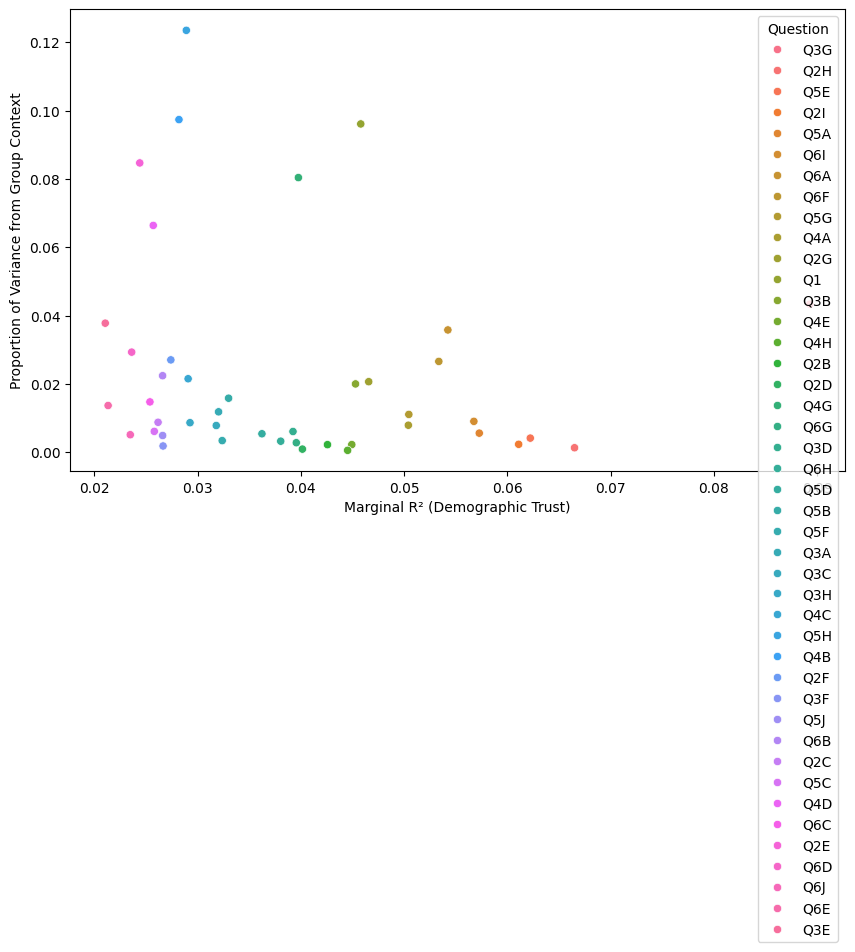

In [90]:
# plot marginal r2 vs group variance proportion
plt.figure(figsize=(10,6))
sns.scatterplot(data=simulationdf, x='Marginal_R2', y='Group_Variance_Prop', hue='Question')
plt.xlabel('Marginal R² (Demographic Trust)')
plt.ylabel('Proportion of Variance from Group Context')

In [91]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Use the cleaner formula API - automatically handles dummy reference categories
formula = "delta ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER) + RACE_diversity + RACE_majority + AGEBRACKET_diversity + AGEBRACKET_majority + EDUCATION_diversity + EDUCATION_majority + PARTYBEFORE_diversity + PARTYBEFORE_majority + GENDER_diversity + GENDER_majority"

detailed_results = []

for question in questions:
    qdf = final_df[final_df['Question'] == question].copy()
    
    # Target variable (raw scale for interpretable effect sizes)
    qdf['delta'] = qdf['delta_human_closer'] 
    
    try:
        # Fit MixedLM
        model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
        
        # --- CALCULATE R-SQUARED COMPONENTS ---
        # 1. Variance of Fixed Effects (Demographics)
        fixed_preds = model.predict(qdf)
        var_f = np.var(fixed_preds)
        
        # 2. Variance of Random Effects (Group context)
        # model.cov_re is the covariance matrix for random effects
        var_r = float(model.cov_re.iloc[0, 0])
        
        # 3. Residual Variance (Unexplained noise)
        var_e = model.scale
        
        # Marginal R2: Variance explained by demographics only
        marginal_r2 = var_f / (var_f + var_r + var_e)
        # Conditional R2: Variance explained by demographics + group clusters
        conditional_r2 = (var_f + var_r) / (var_f + var_r + var_e)
        
        # --- EXTRACT COEFFICIENTS ---
        params = model.params
        pvalues = model.pvalues
        conf_int = model.conf_int()
        
        for feat in params.index:
            if feat == "Group Var": continue
            
            detailed_results.append({
                'Question': question,
                'Variable': feat,
                'Effect_Size': params[feat], # In original scale units
                'P_Value': pvalues[feat],
                'Significant': pvalues[feat] < 0.05,
                'Lower_CI': conf_int.loc[feat, 0],
                'Upper_CI': conf_int.loc[feat, 1],
                'Marginal_R2': marginal_r2,      # Trust in demographics
                'Conditional_R2': conditional_r2,  # Trust in total model
                'Group_Variance_Prop': var_r / (var_f + var_r + var_e) # How much 'Group' matters
            })
            
    except Exception as e:
        print(f"Skipping {question} due to error: {e}")

# Create DataFrame
results_df = pd.DataFrame(detailed_results)

# --- ADD INTERPRETATION HELPERS ---
def get_trust_level(r2):
    if r2 < 0.02: return "Very Low (Noise)"
    if r2 < 0.10: return "Low/Moderate"
    return "High (Strong Signal)"

results_df['Demographic_Trust'] = results_df['Marginal_R2'].apply(get_trust_level)

# Filter for significant results and sort by the strongest predictors
significant_findings = results_df[results_df['P_Value'] < 0.05].sort_values(
    by=['Marginal_R2', 'Effect_Size'], ascending=[False, False]
)

results_df_human = results_df.copy()

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Sem

In [92]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Use the cleaner formula API - automatically handles dummy reference categories
formula = "delta ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER) + RACE_diversity + RACE_majority + AGEBRACKET_diversity + AGEBRACKET_majority + EDUCATION_diversity + EDUCATION_majority + PARTYBEFORE_diversity + PARTYBEFORE_majority + GENDER_diversity + GENDER_majority"

detailed_results = []

for question in questions:
    qdf = final_df[final_df['Question'] == question].copy()
    
    # Target variable (raw scale for interpretable effect sizes)
    qdf['delta'] = qdf['delta_llm_closer'] 
    
    try:
        # Fit MixedLM
        model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
        
        # --- CALCULATE R-SQUARED COMPONENTS ---
        # 1. Variance of Fixed Effects (Demographics)
        fixed_preds = model.predict(qdf)
        var_f = np.var(fixed_preds)
        
        # 2. Variance of Random Effects (Group context)
        # model.cov_re is the covariance matrix for random effects
        var_r = float(model.cov_re.iloc[0, 0])
        
        # 3. Residual Variance (Unexplained noise)
        var_e = model.scale
        
        # Marginal R2: Variance explained by demographics only
        marginal_r2 = var_f / (var_f + var_r + var_e)
        # Conditional R2: Variance explained by demographics + group clusters
        conditional_r2 = (var_f + var_r) / (var_f + var_r + var_e)
        
        # --- EXTRACT COEFFICIENTS ---
        params = model.params
        pvalues = model.pvalues
        conf_int = model.conf_int()
        
        for feat in params.index:
            if feat == "Group Var": continue
            
            detailed_results.append({
                'Question': question,
                'Variable': feat,
                'Effect_Size': params[feat], # In original scale units
                'P_Value': pvalues[feat],
                'Significant': pvalues[feat] < 0.05,
                'Lower_CI': conf_int.loc[feat, 0],
                'Upper_CI': conf_int.loc[feat, 1],
                'Marginal_R2': marginal_r2,      # Trust in demographics
                'Conditional_R2': conditional_r2,  # Trust in total model
                'Group_Variance_Prop': var_r / (var_f + var_r + var_e) # How much 'Group' matters
            })
            
    except Exception as e:
        print(f"Skipping {question} due to error: {e}")

# Create DataFrame
results_df = pd.DataFrame(detailed_results)

# --- ADD INTERPRETATION HELPERS ---
def get_trust_level(r2):
    if r2 < 0.02: return "Very Low (Noise)"
    if r2 < 0.10: return "Low/Moderate"
    return "High (Strong Signal)"

results_df['Demographic_Trust'] = results_df['Marginal_R2'].apply(get_trust_level)

# Filter for significant results and sort by the strongest predictors
significant_findings = results_df[results_df['P_Value'] < 0.05].sort_values(
    by=['Marginal_R2', 'Effect_Size'], ascending=[False, False]
)

results_df_llm = results_df.copy()

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site

In [93]:
model_df = pd.merge(
    results_df_human.reset_index(), 
    results_df_llm.reset_index(), 
    on=['Question', 'Variable'], 
    suffixes=('_human', '_llm'),
    how='inner' # Change to 'left' if you want to keep all human rows even if LLM is missing
)
model_df.head()

#model_df = model_df.sort_values(by='Question').reset_index(drop=True)

,index_human,Question,Variable,Effect_Size_human,P_Value_human,Significant_human,Lower_CI_human,Upper_CI_human,Marginal_R2_human,Conditional_R2_human,...,index_llm,Effect_Size_llm,P_Value_llm,Significant_llm,Lower_CI_llm,Upper_CI_llm,Marginal_R2_llm,Conditional_R2_llm,Group_Variance_Prop_llm,Demographic_Trust_llm
0,0,Q1,Intercept,-0.893017,0.283614,False,-2.525383,0.739349,0.05489,0.11366,...,0,-0.932215,0.057318,False,-1.893409,0.028978,0.053138,0.053138,1.973466e-10,Low/Moderate
1,1,Q1,C(RACE)[T.Asian_non_Hispanic],0.331625,0.699255,False,-1.350821,2.014071,0.05489,0.11366,...,1,0.342281,0.505701,False,-0.665701,1.350263,0.053138,0.053138,1.973466e-10,Low/Moderate
2,2,Q1,C(RACE)[T.Black_non_Hispanic],0.891403,0.226601,False,-0.553498,2.336304,0.05489,0.11366,...,2,0.131031,0.766876,False,-0.735233,0.997294,0.053138,0.053138,1.973466e-10,Low/Moderate
3,3,Q1,C(RACE)[T.Hispanic],-0.106957,0.889835,False,-1.620404,1.406490,0.05489,0.11366,...,3,0.232163,0.620866,False,-0.687792,1.152118,0.053138,0.053138,1.973466e-10,Low/Moderate
4,4,Q1,C(RACE)[T.Other_non_Hispanic],5.053865,0.000899,True,2.070553,8.037176,0.05489,0.11366,...,4,2.098926,0.020895,True,0.317961,3.879892,0.053138,0.053138,1.973466e-10,Low/Moderate


In [94]:
model_overall = model_df[['Question','Marginal_R2_human','Marginal_R2_llm']].drop_duplicates()

In [95]:
model_overall.head()

,Question,Marginal_R2_human,Marginal_R2_llm
0,Q1,0.054890,0.053138
25,Q2B,0.061504,0.036242
50,Q2C,0.039286,0.050570
75,Q2D,0.042663,0.063718
100,Q2E,0.046248,0.068945


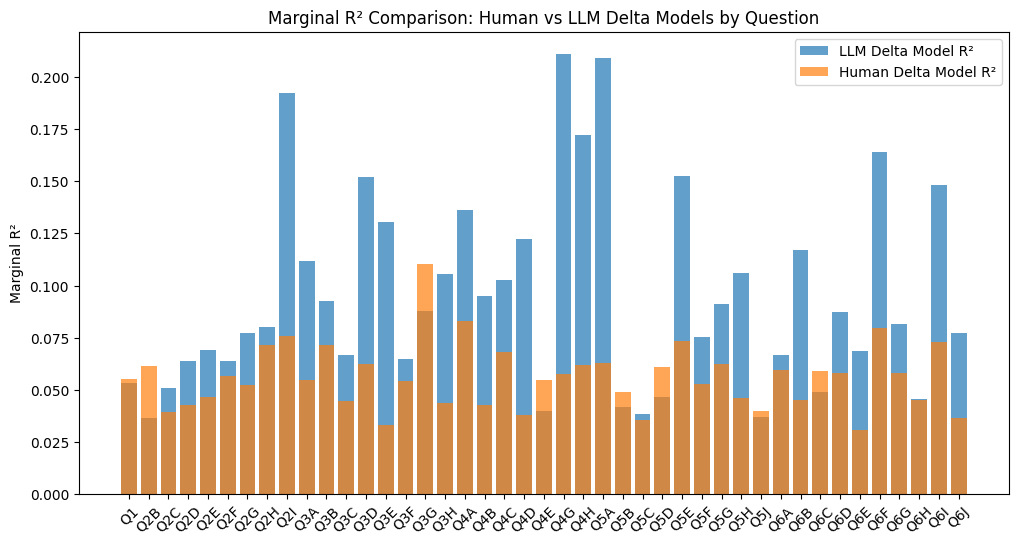

In [96]:
plt.figure(figsize=(12,6))
plt.bar(model_overall['Question'], model_overall['Marginal_R2_llm'], label='LLM Delta Model R²', alpha=0.7)
plt.bar(model_overall['Question'], model_overall['Marginal_R2_human'], label='Human Delta Model R²', alpha=0.7)
plt.xticks(rotation=45)
plt.ylabel('Marginal R²')
plt.title('Marginal R² Comparison: Human vs LLM Delta Models by Question')
plt.legend()

In [97]:
model_df[(model_df['Significant_human'])].groupby('Variable').agg({'Question':'count', 'Effect_Size_human':"mean"}).reset_index().sort_values(by = "Question", ascending=False)

,Variable,Question,Effect_Size_human
9,C(PARTYBEFORE)[T.Republican],14,0.728399
13,C(RACE)[T.Other_non_Hispanic],6,3.335479
11,C(RACE)[T.Black_non_Hispanic],6,1.452882
18,Intercept,5,-1.729653
7,C(GENDER)[T.Male],5,0.394310
10,C(RACE)[T.Asian_non_Hispanic],4,2.165547
12,C(RACE)[T.Hispanic],4,1.235773
5,C(EDUCATION)[T.No_HS_diploma],4,-1.317302
6,C(EDUCATION)[T.Some_college],4,-0.388153
17,GENDER_majority[T.True],3,0.262962


In [98]:
model_df[(model_df['Significant_llm'])].groupby('Variable').agg({'Question':'count', 'Effect_Size_llm':"mean"}).reset_index().sort_values(by = "Question", ascending=False)

,Variable,Question,Effect_Size_llm
9,C(PARTYBEFORE)[T.Republican],24,0.328019
16,Intercept,13,0.539355
8,C(PARTYBEFORE)[T.Independent],12,-0.130131
13,C(RACE)[T.Other_non_Hispanic],11,1.000948
10,C(RACE)[T.Asian_non_Hispanic],9,0.041304
11,C(RACE)[T.Black_non_Hispanic],8,0.261499
12,C(RACE)[T.Hispanic],8,0.427404
14,GENDER_diversity,6,-0.162873
2,C(AGEBRACKET)[T.45_59],5,0.259303
3,C(AGEBRACKET)[T.60plus],5,0.179427


In [101]:
model_df.to_csv("models_coeff.csv")

In [100]:
question_coefs_df[question_coefs_df['significant']].groupby("Model")["Variable"].value_counts()

NameError: name 'question_coefs_df' is not defined

In [ ]:
# group by quesiton and model and variable to get counts of significant variables
significant_counts = question_coefs_df[question_coefs_df['significant']].groupby(['Question', 'Model']).size().reset_index(name='significant_variable_count')
significant_counts.pivot(index='Question', columns='Model', values='significant_variable_count').fillna(0)

Model,Human Delta,LLM Delta
Question,,
Q1,1.0,1.0
Q2B,3.0,0.0
Q2C,0.0,1.0
Q2D,0.0,2.0
Q2E,1.0,3.0
Q2F,4.0,1.0
Q2G,1.0,4.0
Q2H,1.0,2.0
Q2I,6.0,8.0


In [ ]:
# count the overlapping significant variables between human and llm models
overlap_counts = {}
for question in questions:
    human_vars = set(question_coefs_df[(question_coefs_df['Question'] == question) & (question_coefs_df['Model'] == 'Human Delta') & (question_coefs_df['significant'])]['Variable'])
    llm_vars = set(question_coefs_df[(question_coefs_df['Question'] == question) & (question_coefs_df['Model'] == 'LLM Delta') & (question_coefs_df['significant'])]['Variable'])
    overlap = human_vars.intersection(llm_vars)
    overlap_counts[question] = overlap
overlap_counts  

{'Q1': set(),
 'Q2B': set(),
 'Q2C': set(),
 'Q2D': set(),
 'Q2E': set(),
 'Q2F': set(),
 'Q2G': {'RACE_White_non_Hispanic'},
 'Q2H': {'PARTYBEFORE_Republican'},
 'Q2I': {'PARTYBEFORE_Republican'},
 'Q3A': {'PARTYBEFORE_Republican'},
 'Q3B': {'EDUCATION_diversity'},
 'Q3C': {'PARTYBEFORE_Republican'},
 'Q3D': {'AGEBRACKET_45_59'},
 'Q3E': set(),
 'Q3F': set(),
 'Q3G': set(),
 'Q3H': set(),
 'Q4A': {'GENDER_majority', 'RACE_Other_non_Hispanic'},
 'Q4B': set(),
 'Q4C': set(),
 'Q4D': {'RACE_majority'},
 'Q4E': {'RACE_majority'},
 'Q4G': {'PARTYBEFORE_Republican'},
 'Q4H': {'RACE_Black_non_Hispanic',
  'RACE_White_non_Hispanic',
  'RACE_majority'},
 'Q5A': {'Intercept', 'PARTYBEFORE_Republican'},
 'Q5B': {'EDUCATION_diversity', 'RACE_White_non_Hispanic'},
 'Q5C': {'RACE_majority'},
 'Q5D': {'GENDER_Male', 'GENDER_majority'},
 'Q5E': set(),
 'Q5F': {'PARTYBEFORE_Independent', 'RACE_majority'},
 'Q5G': set(),
 'Q5H': {'RACE_majority'},
 'Q5J': set(),
 'Q6A': {'PARTYBEFORE_Republican'},
 'Q6

In [ ]:
# count the most frequently significant variables across all questions for human and llm models
human_significant = question_coefs_df[(question_coefs_df['Model'] == 'Human Delta') & (question_coefs_df['significant'])]
llm_significant = question_coefs_df[(question_coefs_df['Model'] == 'LLM Delta') & (question_coefs_df['significant'])]

In [ ]:
# get question counts for each variable and average sizze of coefficient
human_summary = human_significant.groupby('Variable').agg(
    question_count=('Question', 'nunique'),
    avg_coef=('coef', lambda x: x.astype(float).mean())
).reset_index().sort_values(by='question_count', ascending=False)
llm_summary = llm_significant.groupby('Variable').agg(
    question_count=('Question', 'nunique'),
    avg_coef=('coef', lambda x: x.astype(float).mean())
).reset_index().sort_values(by='question_count', ascending=False)
human_summary

,Variable,question_count,avg_coef
24,RACE_majority,18,-0.053578
22,RACE_White_non_Hispanic,18,0.381489
15,PARTYBEFORE_Republican,11,0.309409
8,EDUCATION_diversity,7,0.011943
18,RACE_Asian_non_Hispanic,7,0.633757
3,AGEBRACKET_diversity,5,-0.249500
20,RACE_Hispanic,5,0.130480
19,RACE_Black_non_Hispanic,5,0.576660
6,EDUCATION_No_HS_diploma,4,-0.519050
7,EDUCATION_Some_college,4,-0.146200


In [ ]:
llm_summary

,Variable,question_count,avg_coef
14,PARTYBEFORE_Republican,24,0.594512
13,PARTYBEFORE_Independent,19,0.331321
23,RACE_majority,16,0.639419
21,RACE_White_non_Hispanic,11,0.832182
20,RACE_Other_non_Hispanic,10,1.919570
2,AGEBRACKET_60plus,7,0.428743
11,GENDER_majority,7,0.218700
18,RACE_Black_non_Hispanic,6,0.672700
7,EDUCATION_Some_college,6,0.254750
10,GENDER_diversity,6,2.077267


In [ ]:
question_coefs_df[question_coefs_df['significant']].to_csv("significant_coefficients.csv")

In [ ]:
# find the group with the diversities most balanced
